In [ ]:
# 🏠 Housing Price Prediction — Linear Regression
#**Dataset:** `housing.csv` — Boston Housing (506 samples, 13 features)  
#**Target:** `MEDV` — Median value of owner-occupied homes in $1000s  
#**Pipeline:** Load → Explore → Preprocess → Train → Evaluate → Predict

SyntaxError: invalid character '—' (U+2014) (4115911236.py, line 2)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [ ]:
# Boston Housing column names (no header in file, whitespace-separated)
COLUMNS = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
           "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

df = pd.read_csv("housing.csv", header=None, names=COLUMNS, sep=r"\s+", engine="python")

print(f"Shape  : {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape  : (506, 14)

Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Step 2 — Exploratory Data Analysis (EDA)

| Column | Description |
|--------|-------------|
| CRIM | Per-capita crime rate |
| ZN | Residential land zoned (%) |
| INDUS | Non-retail business acres (%) |
| CHAS | Charles River dummy (1 = borders river) |
| NOX | Nitric oxide concentration |
| RM | Avg rooms per dwelling |
| AGE | Owner-occupied units built before 1940 (%) |
| DIS | Distance to employment centres |
| RAD | Accessibility to radial highways |
| TAX | Property-tax rate |
| PTRATIO | Pupil-teacher ratio |
| B | 1000(Bk − 0.63)² — proportion of Black residents |
| LSTAT | % lower-status population |
| **MEDV** | **Median home value ($1000s) — TARGET** |

In [36]:
# Basic statistics
print("=== Basic Statistics ===")
print(df.describe().round(2))

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Basic Statistics ===
         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean     3.61   11.36   11.14    0.07    0.55    6.28   68.57    3.80    9.55   
std      8.60   23.32    6.86    0.25    0.12    0.70   28.15    2.11    8.71   
min      0.01    0.00    0.46    0.00    0.38    3.56    2.90    1.13    1.00   
25%      0.08    0.00    5.19    0.00    0.45    5.89   45.02    2.10    4.00   
50%      0.26    0.00    9.69    0.00    0.54    6.21   77.50    3.21    5.00   
75%      3.68   12.50   18.10    0.00    0.62    6.62   94.07    5.19   24.00   
max     88.98  100.00   27.74    1.00    0.87    8.78  100.00   12.13   24.00   

          TAX  PTRATIO       B   LSTAT    MEDV  
count  506.00   506.00  506.00  506.00  506.00  
mean   408.24    18.46  356.67   12.65   22.53  
std    168.54     2.16   91.29    7.14    9.20  
min    187.00    12.60    0.32    1.73    5.00  


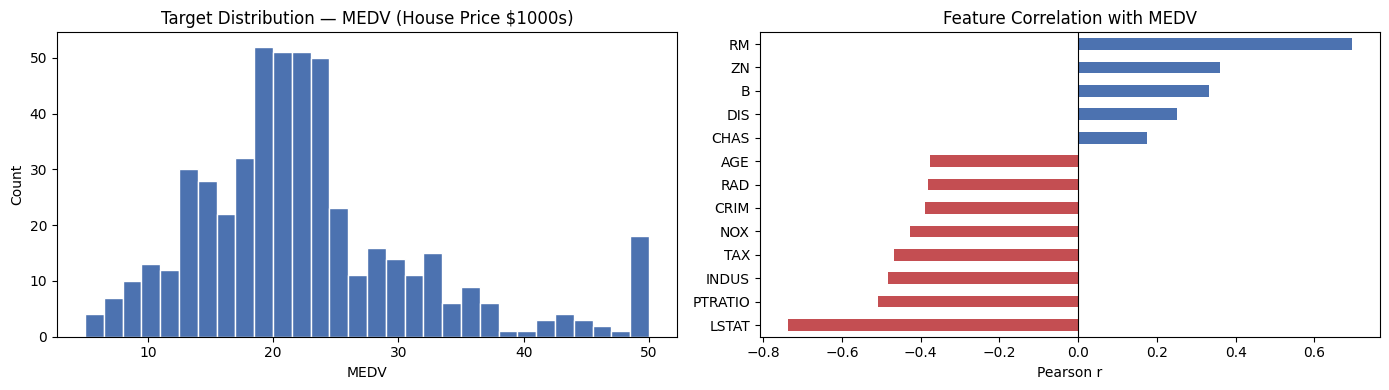

In [37]:
# Target distribution + feature correlations with target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["MEDV"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Target Distribution — MEDV (House Price $1000s)")
axes[0].set_xlabel("MEDV")
axes[0].set_ylabel("Count")

corr = df.corr(numeric_only=True)["MEDV"].drop("MEDV").sort_values()
corr.plot(kind="barh", ax=axes[1], color=["#C44E52" if v < 0 else "#4C72B0" for v in corr])
axes[1].set_title("Feature Correlation with MEDV")
axes[1].set_xlabel("Pearson r")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

Steps performed:
1. **Outlier removal** — drop rows where `MEDV` = 50 (capped values in original data)
2. **Feature engineering** — add `RM²` (rooms squared) and `LSTAT_LOG` (log of lower-status %)
3. **Train / Test split** — 80% train, 20% test
4. **Feature scaling** — `StandardScaler` so all features are on the same scale

In [38]:
# 1. Remove capped outliers (MEDV == 50 is artificially clipped in source data)
df_clean = df[df["MEDV"] < 50].copy()
print(f"Rows after outlier removal: {len(df_clean)}  (removed {len(df) - len(df_clean)})")

# 2. Feature engineering
df_clean["RM2"]       = df_clean["RM"] ** 2         # rooms squared — captures non-linearity
df_clean["LSTAT_LOG"] = np.log1p(df_clean["LSTAT"]) # log-transform right-skewed feature

# 3. Split features and target
FEATURES = [c for c in df_clean.columns if c != "MEDV"]
X = df_clean[FEATURES]
y = df_clean["MEDV"]

# 4. Train / Test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")

# 5. Scale features (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Preprocessing complete.")

Rows after outlier removal: 490  (removed 16)
Train: 392 samples  |  Test: 98 samples
✅ Preprocessing complete.


## Step 4 — Train the Linear Regression Model

In [39]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("✅ Model trained!")

✅ Model trained!


## Step 5 — Evaluate the Model

MAE  (Mean Absolute Error) : $2.20k
RMSE (Root Mean Sq Error)  : $2.84k
R²   (Explained Variance)  : 0.8423  (1.0 = perfect)


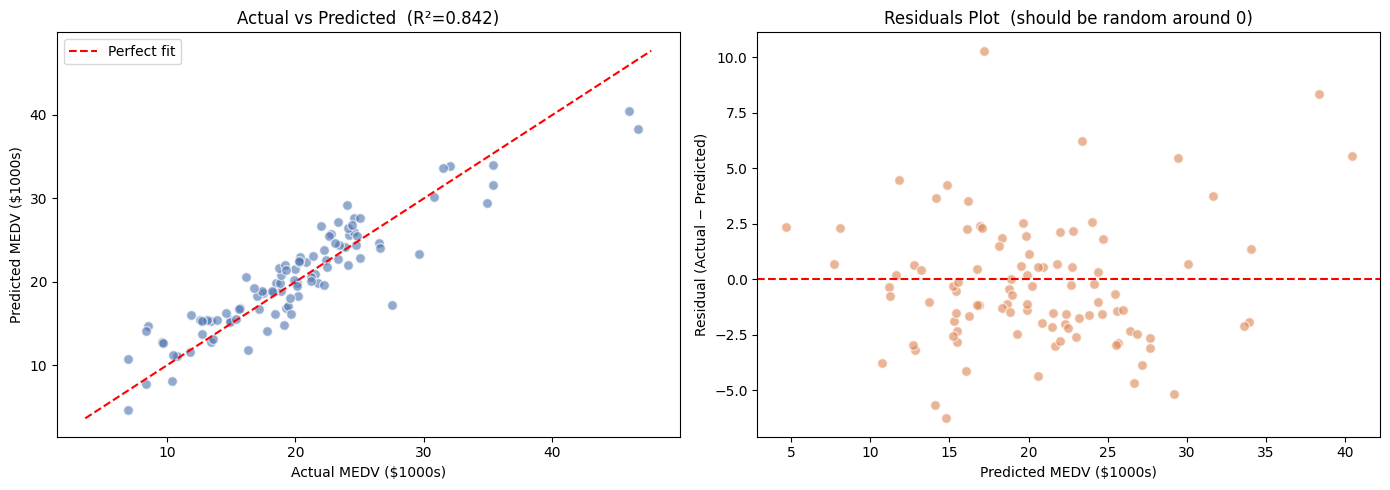

In [40]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error) : ${mae:.2f}k")
print(f"RMSE (Root Mean Sq Error)  : ${rmse:.2f}k")
print(f"R²   (Explained Variance)  : {r2:.4f}  (1.0 = perfect)")

# ── Plot: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.6, color="#4C72B0", edgecolors="white", s=50)
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual MEDV ($1000s)")
axes[0].set_ylabel("Predicted MEDV ($1000s)")
axes[0].set_title(f"Actual vs Predicted  (R²={r2:.3f})")
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color="#DD8452", edgecolors="white", s=50)
axes[1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_xlabel("Predicted MEDV ($1000s)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residuals Plot  (should be random around 0)")

plt.tight_layout()
plt.show()

## Step 6 — Feature Importance & Prediction on New Sample

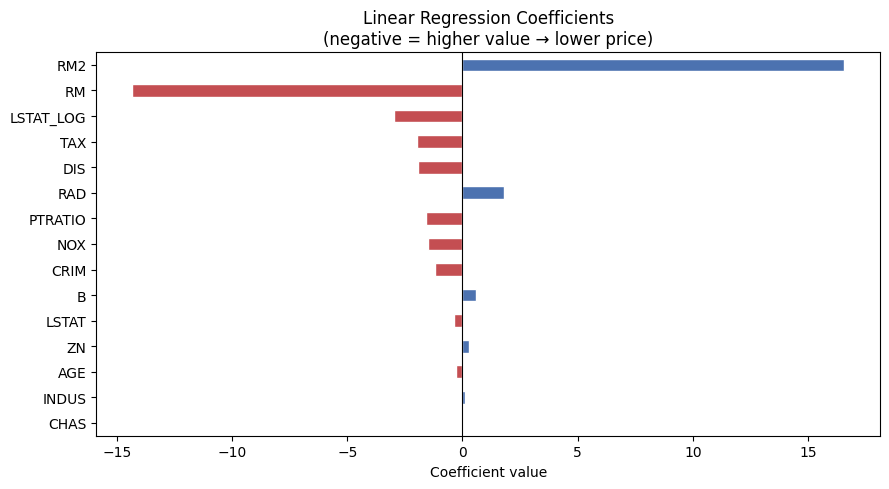

In [41]:
# Feature importance — model coefficients (after scaling, magnitudes are comparable)
coef_df = pd.Series(model.coef_, index=FEATURES).sort_values(key=abs, ascending=True)

plt.figure(figsize=(9, 5))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in coef_df]
coef_df.plot(kind="barh", color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients\n(negative = higher value → lower price)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

In [42]:
# Predict on one real test sample
sample_X   = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample_X)
actual    = y_test.iloc[0]
predicted = model.predict(sample_scaled)[0]

print("=" * 45)
print(f"  Actual price    : ${actual:.1f}k")
print(f"  Predicted price : ${predicted:.1f}k")
print(f"  Error           : ${abs(actual - predicted):.1f}k")
print("=" * 45)

  Actual price    : $19.1k
  Predicted price : $14.8k
  Error           : $4.3k


In [43]:
import pickle
with open("linear_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("✅ Model saved to 'linear_model.pkl'")
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved to 'scaler.pkl'")    


✅ Model saved to 'linear_model.pkl'
✅ Scaler saved to 'scaler.pkl'
